# Selección del mejor modelo

### By:
Karen Ninco

### Date:
2026-08-25

### Description:

Se realiza el proceso de selección manual del mejor modelo de machine learning para el dataset de corazón, reutilizando el pipeline de preprocesamiento construido en la Actividad 4 (Feature Engineering, [04.FeatureEngineering-kgnl-20260821.ipynb](../4-feat_eng/04.FeatureEngineering-kgnl-20260821.ipynb)). El modelo final seleccionado debe superar el desempeño del modelo baseline heurístico de la Actividad 5 (Modelo Base, [05.BaselineModel-kgnl-20260825.ipynb](../5-models/05.BaselineModel-kgnl-20260825.ipynb)): recall ~0.80 y accuracy ~0.77.

## 📚 Import  libraries

In [109]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import f_oneway
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

## 💾 Load data

In [110]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
corazon_df = pd.read_parquet(DATA_DIR / "02_intermediate/corazon_clean.parquet", engine="pyarrow")

print("Pandas version: ", pd.__version__)

Pandas version:  3.0.5


## 👷 Data preparation

Se reproducen exactamente los mismos pasos de limpieza y Feature Selection realizados en la Actividad 4 (Feature Engineering, [04.FeatureEngineering-kgnl-20260821.ipynb](../4-feat_eng/04.FeatureEngineering-kgnl-20260821.ipynb)): selección de las columnas relevantes (incluyendo el descarte de `fbs` y `rest_bp` por su baja asociación con `disease`), eliminación de filas sin valor en la variable objetivo y eliminación de duplicados, para llegar al mismo dataset final de 473 filas únicas.

In [111]:
selected_features = [
    "age",
    "sex",
    "chest_pain",
    "chol",
    "rest_ecg",
    "max_hr",
    "exang",
    "old_peak",
    "slope",
    "ca",
    "thal",
    "disease",
]
corazon_features = corazon_df[selected_features]
corazon_features = corazon_features.dropna(subset=["disease"])
corazon_features.loc[:, "disease"] = corazon_features["disease"].astype(int)
corazon_features = corazon_features.drop_duplicates()
corazon_features.info()

<class 'pandas.DataFrame'>
Index: 473 entries, 0 to 1496
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         456 non-null    float64 
 1   sex         424 non-null    category
 2   chest_pain  402 non-null    category
 3   chol        401 non-null    float64 
 4   rest_ecg    357 non-null    category
 5   max_hr      383 non-null    Int16   
 6   exang       402 non-null    boolean 
 7   old_peak    403 non-null    float64 
 8   slope       403 non-null    category
 9   ca          426 non-null    Int8    
 10  thal        441 non-null    category
 11  disease     473 non-null    boolean 
dtypes: Int16(1), Int8(1), boolean(2), category(5), float64(3)
memory usage: 21.6 KB


## 🔧 Feature Engineering

Se reproduce exactamente el mismo `ColumnTransformer` construido en la Actividad 4: pipeline numérico (`SimpleImputer` con mediana + `StandardScaler`), pipeline booleano (`SimpleImputer` con moda), pipeline categórico nominal (`SimpleImputer` con moda + `OneHotEncoder`) y pipeline categórico ordinal para `slope` (`SimpleImputer` con moda + `OrdinalEncoder`).

Única diferencia respecto a la Actividad 4: tanto `OneHotEncoder` como `OrdinalEncoder` se configuran para manejar categorías no vistas (`handle_unknown="ignore"` y `handle_unknown="use_encoded_value", unknown_value=-1`, respectivamente) en vez de sus valores por defecto (que lanzan error). Esto es necesario para la Learning Curve más adelante, que evalúa con `ShuffleSplit` sobre folds de entrenamiento pequeños que pueden no contener alguna categoría rara (por ejemplo, `"ST-T wave abnormality"` en `rest_ecg`, o `'3'` en `slope`); con los valores por defecto, esos folds fallan al transformar el fold de test. No afecta el comportamiento en el split de train/test normal.

In [112]:
cols_numeric = ["age", "chol", "max_hr", "old_peak", "ca"]
cols_boolean = ["exang"]
cols_categoric = ["sex", "chest_pain", "rest_ecg", "thal"]
cols_categoric_ord = ["slope"]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

boolean_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

categorical_ord_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, cols_numeric),
        ("boolean", boolean_pipe, cols_boolean),
        ("categoric", categorical_pipe, cols_categoric),
        ("categoric ordinales", categorical_ord_pipe, cols_categoric_ord),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('boolean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

### Train / Test split

In [113]:
X_features = corazon_features.drop("disease", axis="columns")
Y_target = corazon_features["disease"]

# 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=42
)
x_train.shape, y_train.shape

((378, 11), (378,))

In [114]:
x_test.shape, y_test.shape

((95, 11), (95,))

### Ejemplo de la transformación del pipeline

In [115]:
preprocessor.fit(x_train)
feature_names = preprocessor.get_feature_names_out()

x_test_transformed = preprocessor.transform(x_test)
x_test_transformed = pd.DataFrame(x_test_transformed, columns=feature_names)
x_test_transformed.head()

,numeric__age,numeric__chol,numeric__max_hr,numeric__old_peak,numeric__ca,boolean__exang,categoric__sex_Female,categoric__sex_Male,categoric__chest_pain_asymptomatic,categoric__chest_pain_nonanginal,categoric__chest_pain_nontypical,categoric__chest_pain_typical,categoric__rest_ecg_ST-T wave abnormality,categoric__rest_ecg_left ventricular hypertrophy,categoric__rest_ecg_normal,categoric__thal_fixed,categoric__thal_normal,categoric__thal_reversable,categoric ordinales__slope
0,-0.209961,-0.065043,1.134421,-0.920568,2.653209,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.851386,-0.084903,0.115291,0.330497,-0.667695,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,0.733459,-0.084903,-0.175889,-0.026950,-0.667695,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0.497604,-0.084903,0.115291,-0.205674,1.546241,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1.912734,-1.991430,-1.195019,0.509220,-0.667695,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## 🤖 Modelos

Se evaluarán 4 modelos de machine learning: Regresión Logística (`LogisticRegression`), Análisis Discriminante Lineal (`LinearDiscriminantAnalysis`), Árbol de Decisión (`DecisionTreeClassifier`) y Random Forest (`RandomForestClassifier`).

### Funciones auxiliares

In [116]:
def summarize_classification(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred, normalize=True)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    return {"accuracy": acc, "precision": prec, "recall": recall, "f1": f1, "roc": roc}


def build_model(classifier_fn, preprocessor, data_params, test_frac=0.2):
    name_of_y_col = data_params["name_of_y_col"]
    names_of_x_cols = data_params["names_of_x_cols"]
    dataset = data_params["dataset"]
    X = dataset[names_of_x_cols]
    Y = dataset[name_of_y_col]
    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_frac, stratify=Y, random_state=42
    )
    classifier_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", classifier_fn)])
    model = classifier_pipe.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_pred_train = model.predict(x_train)
    train_summary = summarize_classification(y_train, y_pred_train)
    test_summary = summarize_classification(y_test, y_pred)
    return {"train": train_summary, "test": test_summary}

## 🔎 Primera selección de modelos

Se entrenan y evalúan los 4 modelos con hiperparámetros por defecto, para descartar los de peor desempeño antes de pasar a la validación cruzada.

In [117]:
result_dict = {}
models = {
    "logistic": LogisticRegression(solver="liblinear", random_state=42),
    "lda": LinearDiscriminantAnalysis(),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "random_forest": RandomForestClassifier(random_state=42),
}
data_params = {
    "name_of_y_col": "disease",
    "names_of_x_cols": list(X_features.columns),
    "dataset": corazon_features,
}
for model_name, model in models.items():
    result_dict[model_name] = build_model(model, preprocessor, data_params)

### Comparación de modelos (train vs test)

In [118]:
metrics = ["accuracy", "precision", "recall", "f1", "roc"]

df_train = pd.DataFrame(
    {model_name: result_dict[model_name]["train"] for model_name in result_dict}
).T
df_test = pd.DataFrame(
    {model_name: result_dict[model_name]["test"] for model_name in result_dict}
).T
df_train

,accuracy,precision,recall,f1,roc
logistic,0.835979,0.875000,0.769231,0.818713,0.833595
lda,0.846561,0.892405,0.774725,0.829412,0.843995
decision_tree,1.000000,1.000000,1.000000,1.000000,1.000000
random_forest,1.000000,1.000000,1.000000,1.000000,1.000000


In [119]:
df_test

,accuracy,precision,recall,f1,roc
logistic,0.810526,0.833333,0.760870,0.795455,0.809006
lda,0.821053,0.853659,0.760870,0.804598,0.819210
decision_tree,0.852632,0.900000,0.782609,0.837209,0.850488
random_forest,0.915789,0.931818,0.891304,0.911111,0.915040


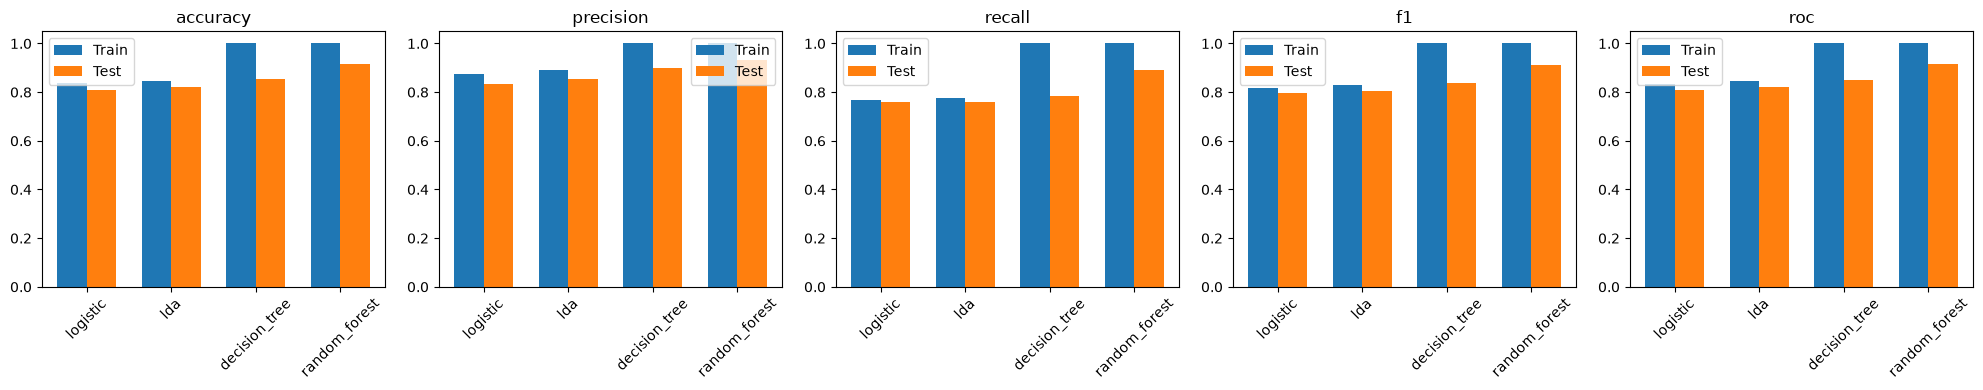

In [120]:
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4))
x = np.arange(len(df_train.index))
width = 0.35

for ax, metric in zip(axes, metrics, strict=True):
    ax.bar(x - width / 2, df_train[metric], width, label="Train")
    ax.bar(x + width / 2, df_test[metric], width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(df_train.index, rotation=45)
    ax.set_title(metric)
    ax.legend()

plt.tight_layout()
plt.show()

In [121]:
overfit_threshold = 0.1
similar_threshold = 0.05
model_names = list(df_test.index)

print("=== Overfitting (train - test > 0.1) ===")
for metric in metrics:
    for model_name in model_names:
        diff = df_train.loc[model_name, metric] - df_test.loc[model_name, metric]
        if diff > overfit_threshold:
            print(
                f"[{metric}] {model_name}: train={df_train.loc[model_name, metric]:.4f}, "
                f"test={df_test.loc[model_name, metric]:.4f}, diff={diff:.4f}"
            )

print("\n=== Bajo desempeño (test < promedio de los modelos) ===")
for metric in metrics:
    mean_metric = df_test[metric].mean()
    for model_name in model_names:
        value = df_test.loc[model_name, metric]
        if value < mean_metric:
            print(f"[{metric}] {model_name}: test={value:.4f} < promedio={mean_metric:.4f}")

print("\n=== Desempeño similar entre modelos (diferencia < 0.05) ===")
for metric in metrics:
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            diff = abs(df_test.loc[model_names[i], metric] - df_test.loc[model_names[j], metric])
            if diff < similar_threshold:
                print(f"[{metric}] {model_names[i]} vs {model_names[j]}: diff={diff:.4f}")

=== Overfitting (train - test > 0.1) ===
[accuracy] decision_tree: train=1.0000, test=0.8526, diff=0.1474
[recall] decision_tree: train=1.0000, test=0.7826, diff=0.2174
[recall] random_forest: train=1.0000, test=0.8913, diff=0.1087
[f1] decision_tree: train=1.0000, test=0.8372, diff=0.1628
[roc] decision_tree: train=1.0000, test=0.8505, diff=0.1495

=== Bajo desempeño (test < promedio de los modelos) ===
[accuracy] logistic: test=0.8105 < promedio=0.8500
[accuracy] lda: test=0.8211 < promedio=0.8500
[precision] logistic: test=0.8333 < promedio=0.8797
[precision] lda: test=0.8537 < promedio=0.8797
[recall] logistic: test=0.7609 < promedio=0.7989
[recall] lda: test=0.7609 < promedio=0.7989
[recall] decision_tree: test=0.7826 < promedio=0.7989
[f1] logistic: test=0.7955 < promedio=0.8371
[f1] lda: test=0.8046 < promedio=0.8371
[roc] logistic: test=0.8090 < promedio=0.8484
[roc] lda: test=0.8192 < promedio=0.8484

=== Desempeño similar entre modelos (diferencia < 0.05) ===
[accuracy] logis

## 🔁 Validación cruzada

Se evaluarán con `KFold` (10 particiones) los modelos que no se descarten a partir de los resultados de la celda anterior (overfitting, bajo desempeño o desempeño similar). Por ahora se deja el código preparado para los 4 modelos; se ajustará la lista `models_cv` después de revisar esos resultados.

In [122]:
models_cv = {
    "logistic": LogisticRegression(solver="liblinear", random_state=42),
    "lda": LinearDiscriminantAnalysis(),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "random_forest": RandomForestClassifier(random_state=42),
}
scoring_metrics = ["accuracy", "f1", "precision", "recall"]
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {metric: {} for metric in scoring_metrics}
for model_name, model in models_cv.items():
    model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for metric in scoring_metrics:
        cv_results[metric][model_name] = cross_val_score(
            model_pipe, x_train, y_train, cv=kfold, scoring=metric
        )
cv_results_df = {metric: pd.DataFrame(cv_results[metric]) for metric in scoring_metrics}

### Tabla resumen (media y desviación estándar por modelo y métrica)

In [123]:
mean_std_df = pd.DataFrame(
    {
        (metric, stat): {
            model_name: getattr(cv_results_df[metric][model_name], stat)()
            for model_name in models_cv
        }
        for metric in scoring_metrics
        for stat in ["mean", "std"]
    }
)
mean_std_df

accuracy                  f1           precision            \
                   mean       std      mean       std      mean       std   
logistic       0.814723  0.065935  0.797471  0.073707  0.846473  0.061842   
lda            0.817496  0.054567  0.797516  0.064122  0.850804  0.057851   
decision_tree  0.730441  0.088541  0.712391  0.104048  0.730038  0.160328   
random_forest  0.825391  0.059897  0.809615  0.077940  0.826757  0.080077   

                 recall            
                   mean       std  
logistic       0.764250  0.119322  
lda            0.764488  0.122826  
decision_tree  0.713877  0.102843  
random_forest  0.805255  0.115271

### Boxplots de validación cruzada por métrica

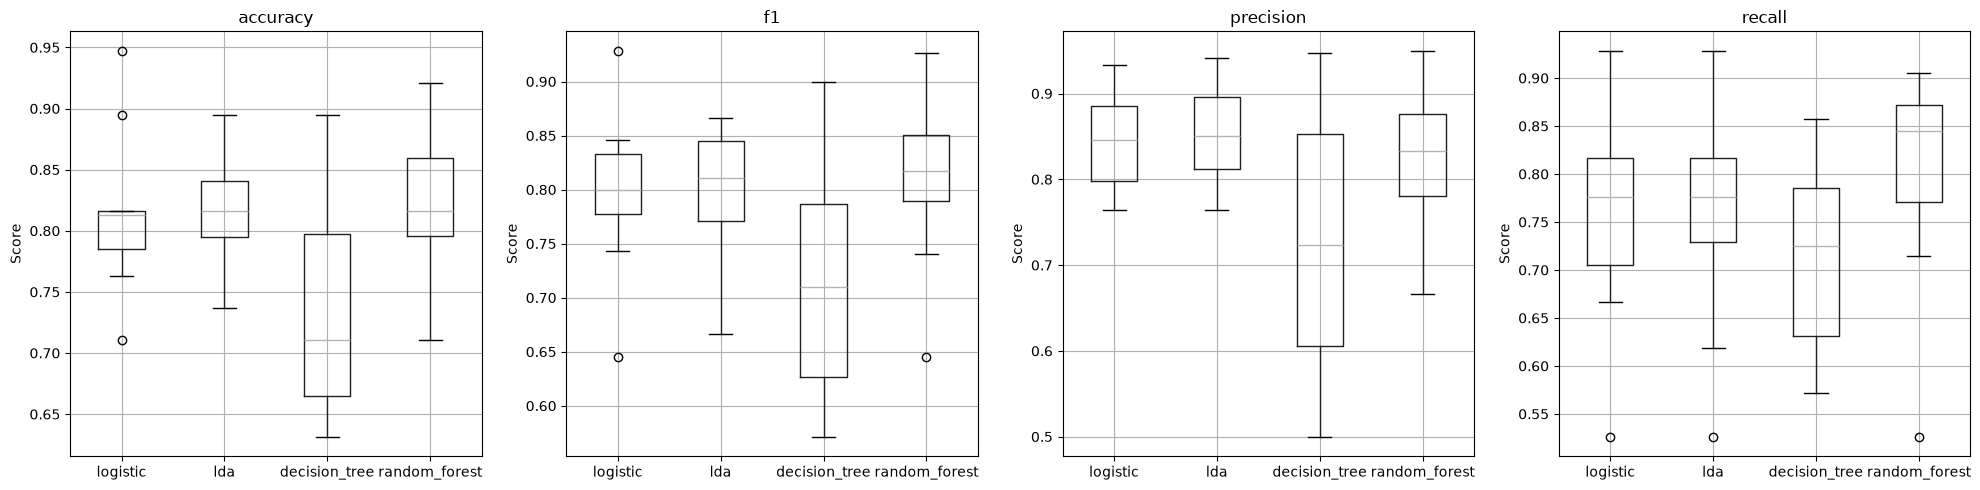

In [124]:
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(20, 5))
for ax, metric in zip(axes, scoring_metrics, strict=True):
    cv_results_df[metric].boxplot(ax=ax)
    ax.set_title(metric)
    ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 🎯 Selección de la métrica más importante

Al igual que en la Actividad 5 (Modelo BaseLine), se prioriza el **recall** como métrica principal para seleccionar el modelo. En el contexto de este proyecto, el recall mide qué proporción de los pacientes que realmente tienen la enfermedad son correctamente identificados por el modelo. Un falso negativo (predecir "sano" cuando el paciente sí tiene la enfermedad) tiene consecuencias clínicas más graves que un falso positivo, por lo que minimizar los falsos negativos —es decir, maximizar el recall— es el criterio más relevante para este problema. Las demás métricas (accuracy, precision, f1, ROC-AUC) se reportan como contexto adicional, pero el recall es el criterio de decisión.

## 📐 Comparación estadística

Se usa `scipy.stats.f_oneway` (ANOVA) sobre los resultados de validación cruzada de recall de los 4 modelos, con un nivel de significancia `alpha = 0.05`, para determinar si existe una diferencia estadísticamente significativa entre ellos.

In [125]:
alpha = 0.05
recall_samples = [cv_results_df["recall"][model_name] for model_name in models_cv]
statistic, p_value = f_oneway(*recall_samples)

print(f"Estadístico F: {statistic:.4f}")
print(f"p-valor: {p_value:.4f}")

if p_value < alpha:
    print(
        f"p-valor < {alpha}: existe una diferencia estadísticamente significativa entre los modelos."
    )
else:
    print(
        f"p-valor >= {alpha}: no existe una diferencia estadísticamente significativa entre los modelos."
    )

Estadístico F: 1.0524
p-valor: 0.3813
p-valor >= 0.05: no existe una diferencia estadísticamente significativa entre los modelos.


## 📌 Conclusión de la comparación estadística

La prueba ANOVA sobre los scores de recall obtenidos por validación cruzada (10-fold) entre los 4 modelos arrojó F = 1.0524, p = 0.3813. Como p > 0.05, no existe evidencia estadística suficiente para afirmar que las diferencias de recall entre los modelos sean significativas.

Esto no significa que los modelos sean equivalentes en la práctica: las diferencias observadas en las medias de recall (logistic 0.7643, lda 0.7645, decision_tree 0.7139, random_forest 0.8053) siguen siendo la mejor evidencia disponible para orientar la selección, dado que la prueba estadística no descarta ninguna de ellas por sí sola. Por eso se decide continuar con los dos modelos de mejor desempeño observado (Logistic Regression y Random Forest) para la etapa de ajuste de hiperparámetros, descartando Decision Tree (peor recall y mayor overfitting) y LDA (prácticamente idéntico a Logistic, sin aportar una alternativa distinta).

## 🎛️ Ajuste de hiperparámetros

Con base en los resultados de la primera selección de modelos y la validación cruzada (celdas anteriores), se descartan dos de los cuatro modelos evaluados:

- `decision_tree`: presenta el recall más bajo en validación cruzada y el mayor overfitting (mayor diferencia entre train y test) de los 4 modelos.
- `lda`: sus resultados son prácticamente idénticos a los de `logistic` en todas las métricas, por lo que no aporta información adicional.

Se afinan los hiperparámetros de los dos modelos restantes, `random_forest` y `logistic` (Regresión Logística), usando `GridSearchCV` con validación cruzada, optimizando la métrica `recall`.

In [126]:
from sklearn.model_selection import GridSearchCV

score = "recall"
parameters_logistic = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.1, 0.4, 0.8, 1, 2, 5],
}
modelo_logistic = LogisticRegression(solver="liblinear", random_state=42)
logistic_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo_logistic)])
grid_search_logistic = GridSearchCV(
    logistic_pipe, parameters_logistic, cv=5, scoring=score, return_train_score=True
)
grid_search_logistic.fit(x_train, y_train)
grid_search_logistic.best_params_

/home/karen/Dataset-Corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/karen/Dataset-Corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/karen/Dataset-Corazon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' 

{'model__C': 0.1, 'model__penalty': 'l2'}

In [127]:
parameters_rf = {
    "model__max_depth": [3, 4, 5, 7, 9],
    "model__max_features": [2, 3, 4, 5, 6, 7],
    "model__criterion": ["gini", "entropy"],
}
randomforest_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42)),
    ]
)
grid_search_rf = GridSearchCV(
    randomforest_pipe, parameters_rf, cv=5, scoring=score, return_train_score=True
)
grid_search_rf.fit(x_train, y_train)
grid_search_rf.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 9,
 'model__max_features': 6}

### Evaluación con los mejores hiperparámetros

Se evalúan `grid_search_logistic.best_estimator_` y `grid_search_rf.best_estimator_` (ya entrenados sobre `x_train` por `GridSearchCV`) sobre el conjunto de prueba (`x_test`).

In [128]:
y_pred_logistic = grid_search_logistic.best_estimator_.predict(x_test)
summarize_classification(y_test, y_pred_logistic)

{'accuracy': 0.8,
 'precision': 0.8292682926829268,
 'recall': 0.7391304347826086,
 'f1': 0.7816091954022989,
 'roc': 0.798136645962733}

In [129]:
y_pred_rf = grid_search_rf.best_estimator_.predict(x_test)
summarize_classification(y_test, y_pred_rf)

{'accuracy': 0.8631578947368421,
 'precision': 0.8666666666666667,
 'recall': 0.8478260869565217,
 'f1': 0.8571428571428571,
 'roc': 0.8626885536823424}

## ✅ Evaluación Final

In [130]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
)

### Regresión Logística

In [131]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

         0.0       0.78      0.86      0.82        49
         1.0       0.83      0.74      0.78        46

    accuracy                           0.80        95
   macro avg       0.80      0.80      0.80        95
weighted avg       0.80      0.80      0.80        95



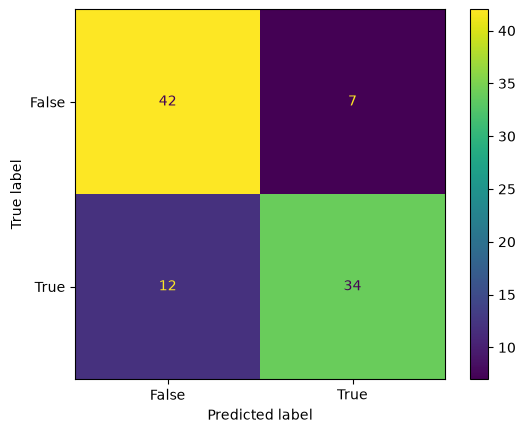

In [132]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logistic)
plt.show()

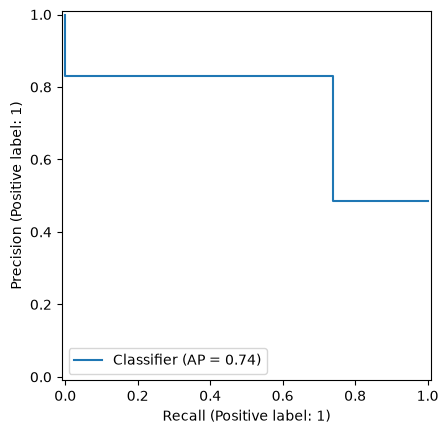

In [133]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred_logistic)
plt.show()

### Random Forest

In [134]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87        49
         1.0       0.87      0.85      0.86        46

    accuracy                           0.86        95
   macro avg       0.86      0.86      0.86        95
weighted avg       0.86      0.86      0.86        95



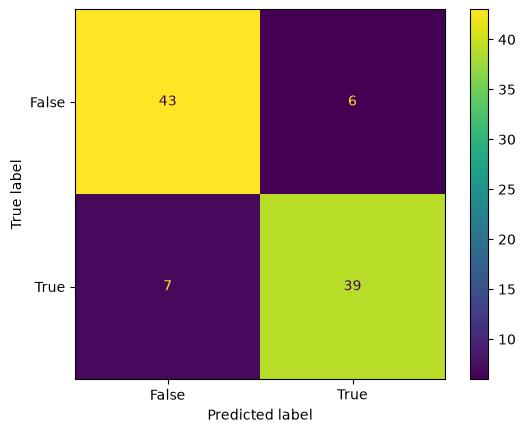

In [135]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

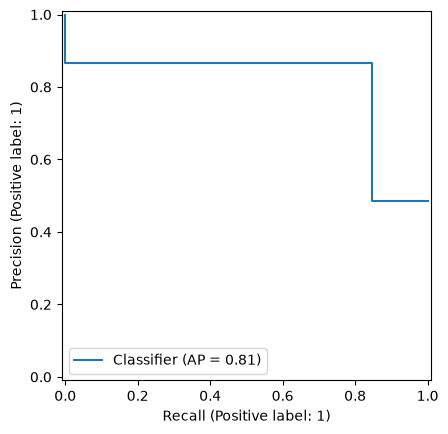

In [136]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

## Comparación de modelos

Random Forest supera a la Regresión Logística en las 5 métricas evaluadas sobre el conjunto de prueba, con una ventaja particularmente relevante en recall (0.848 vs 0.739) — la métrica que priorizamos por su importancia clínica (minimizar falsos negativos). La curva ROC comparativa confirma visualmente esta diferencia: la curva de Random Forest se mantiene por encima de la de Regresión Logística, indicando mejor capacidad de discriminación entre pacientes con y sin enfermedad.

**Random Forest es seleccionado como el modelo final** para este proyecto.

### Curva ROC comparativa

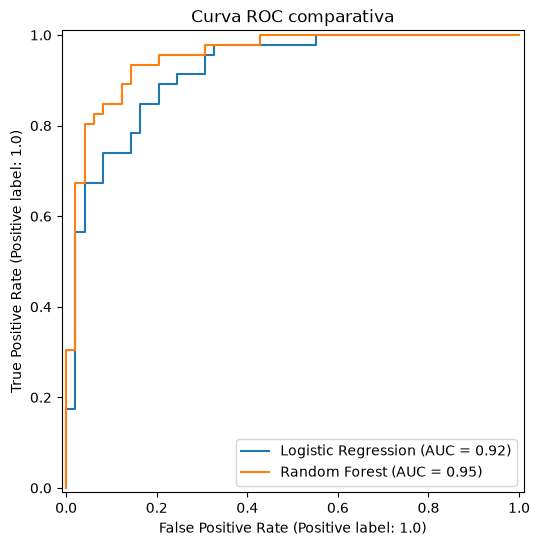

In [137]:
fig, ax = plt.subplots(figsize=(8, 6))
log_plot = RocCurveDisplay.from_estimator(
    grid_search_logistic.best_estimator_,
    x_test,
    y_test,
    ax=ax,
    name="Logistic Regression",
)
rf_plot = RocCurveDisplay.from_estimator(
    grid_search_rf.best_estimator_, x_test, y_test, ax=ax, name="Random Forest"
)
ax.set_title("Curva ROC comparativa")
plt.show()

## 📈 Learning Curve

Se realiza el análisis de Learning Curve sobre el modelo final seleccionado. Como se confirmó en la sección de "Comparación de modelos" (Random Forest supera a Logistic en las 5 métricas de evaluación, incluyendo recall), `best_model = grid_search_rf.best_estimator_` es el modelo final (Random Forest con los hiperparámetros afinados por GridSearchCV).

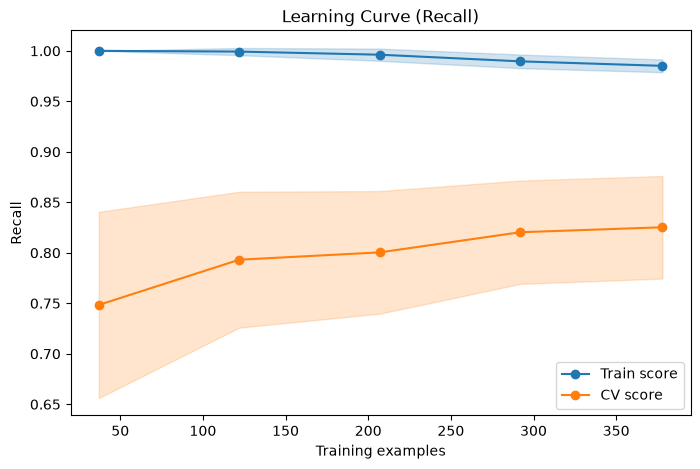

In [138]:
from sklearn.model_selection import ShuffleSplit, learning_curve

best_model = grid_search_rf.best_estimator_

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    best_model,
    X_features,
    Y_target,
    cv=ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="recall",
    return_times=True,
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
test_scores_mean = test_scores.mean(axis=1)
test_scores_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores_mean, "o-", color="tab:blue", label="Train score")
ax.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
    color="tab:blue",
)
ax.plot(train_sizes, test_scores_mean, "o-", color="tab:orange", label="CV score")
ax.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
    color="tab:orange",
)
ax.set_xlabel("Training examples")
ax.set_ylabel("Recall")
ax.set_title("Learning Curve (Recall)")
ax.legend(loc="best")
plt.show()

In [139]:
print("Training Sizes:", train_sizes)
print("Train Scores Mean:", train_scores_mean)
print("Train Scores Std:", train_scores_std)
print("CV Scores Mean:", test_scores_mean)
print("CV Scores Std:", test_scores_std)

Training Sizes: [ 37 122 207 292 378]
Train Scores Mean: [1.         0.9992764  0.99618591 0.9896079  0.98515209]
Train Scores Std: [0.         0.00355223 0.00602965 0.00673719 0.00629667]
CV Scores Mean: [0.74839137 0.79317168 0.80042023 0.82037198 0.82528502]
CV Scores Std: [0.09218034 0.0672669  0.06070701 0.05117794 0.05078009]


### ⏱️ Escalabilidad del modelo

Se grafican los tiempos de ajuste (`fit_times`) y predicción (`score_times`) obtenidos en la Learning Curve, en función del tamaño del conjunto de entrenamiento.

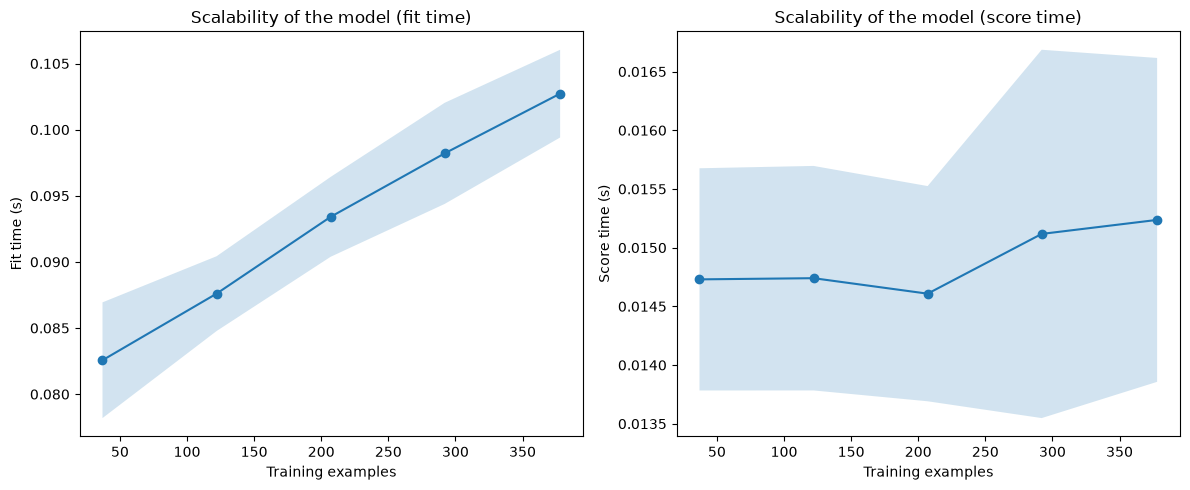

In [140]:
fit_times_mean = fit_times.mean(axis=1)
fit_times_std = fit_times.std(axis=1)
score_times_mean = score_times.mean(axis=1)
score_times_std = score_times.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_sizes, fit_times_mean, "o-")
axes[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.2,
)
axes[0].set_xlabel("Training examples")
axes[0].set_ylabel("Fit time (s)")
axes[0].set_title("Scalability of the model (fit time)")

axes[1].plot(train_sizes, score_times_mean, "o-")
axes[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.2,
)
axes[1].set_xlabel("Training examples")
axes[1].set_ylabel("Score time (s)")
axes[1].set_title("Scalability of the model (score time)")

plt.tight_layout()
plt.show()

In [141]:
print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)

Fit Times Mean: [0.08256767 0.08760066 0.09340734 0.09820879 0.10272369]
Fit Times Std: [0.0043744  0.00282743 0.00301935 0.00382291 0.00331719]
Score Times Mean: [0.01472992 0.01474001 0.0146081  0.01511716 0.01523656]
Score Times Std: [0.00094656 0.00095639 0.00091676 0.00156898 0.00137965]


## 💾 Guardar el modelo

Se guarda el modelo final (`best_model`) usando `joblib`, para poder reutilizarlo sin necesidad de reentrenarlo.

In [142]:
from joblib import dump

dump(best_model, "../../models/corazon_classification-model-v1.joblib")

['../../models/corazon_classification-model-v1.joblib']

## 🔍 Probar el modelo guardado

Se carga el modelo guardado desde disco y se prueba con una muestra de `x_test`, para confirmar que las predicciones se pueden reproducir correctamente.

In [143]:
from joblib import load

my_model = load("../../models/corazon_classification-model-v1.joblib")
x_test.head()

,age,sex,chest_pain,chol,rest_ecg,max_hr,exang,old_peak,slope,ca,thal
179,53.0,Male,nonanginal,246.0,left ventricular hypertrophy,173,False,0.0,1,3,normal
1421,62.0,NaN,NaN,NaN,NaN,<NA>,True,1.4,2,0,normal
1019,61.0,Female,asymptomatic,NaN,left ventricular hypertrophy,146,True,1.0,2,0,reversable
1205,59.0,Male,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,2,fixed
273,71.0,Female,asymptomatic,149.0,normal,125,False,1.6,2,0,normal


In [144]:
my_model.predict(x_test.head())

array([0., 0., 1., 1., 0.])

## 📊 Analysis of Results

El modelo final seleccionado, Random Forest con hiperparámetros afinados (criterion="entropy", max_depth=9, max_features=6), obtuvo sobre el conjunto de prueba (95 pacientes): accuracy 0.863, precision 0.867, recall 0.848, f1 0.857 y ROC AUC 0.863.

Comparado con el modelo baseline heurístico de la Actividad 5 (recall ~0.80, accuracy ~0.77), Random Forest lo supera claramente en ambas métricas (recall 0.848 vs 0.80, accuracy 0.863 vs 0.77) — cumpliendo el requisito del curso de que el modelo seleccionado debe superar al baseline. La Regresión Logística afinada (recall 0.739), en cambio, quedó por debajo del baseline en recall, a pesar de tener mejor accuracy que este.

Aunque la prueba estadística ANOVA sobre los 4 modelos originales no encontró diferencias significativas en recall (p=0.3813), el desempeño observado consistentemente favoreció a Random Forest en la primera selección, en la validación cruzada y en la evaluación final con hiperparámetros afinados — por lo que se considera la elección más robusta disponible con los modelos evaluados.

La Learning Curve reveló una limitación importante: persiste una brecha considerable entre el recall de entrenamiento (0.985-1.0) y el de validación cruzada (0.748-0.825) incluso después de limitar max_depth=9, indicando que el modelo aún memoriza parcialmente los datos de entrenamiento. Sin embargo, el recall de validación cruzada muestra una tendencia ascendente clara a medida que aumenta el tamaño de la muestra (de 0.748 con 37 filas a 0.825 con las 378 disponibles), sin señales de haber "tocado techo" — sugiriendo que más datos de entrenamiento probablemente seguirían mejorando el desempeño del modelo.

## 💡 Recomendaciones

Recolectar más datos: dado que solo se cuenta con 473 filas únicas (378 de entrenamiento) y la Learning Curve muestra una tendencia de mejora continua sin estabilizarse, ampliar el tamaño de la muestra sería la mejora con mayor potencial de impacto para este modelo.

Reducir el overfitting residual: explorar hiperparámetros adicionales de Random Forest (min_samples_leaf, min_samples_split) o técnicas de regularización más agresivas, ya que la brecha entre train y validación cruzada, aunque menor que con los valores por defecto, sigue siendo considerable.

Revisar la decisión sobre duplicados: como se documentó en las Actividades 4 y 5, existe la alternativa de usar el dataset completo con 2919 filas (incluyendo duplicados) en vez de las 473 filas únicas — con más datos disponibles, valdría la pena evaluar si el desempeño mejora sin comprometer la validez estadística del modelo.

Explorar modelos más complejos: técnicas de ensamble más avanzadas como Gradient Boosting (por ejemplo XGBoost o LightGBM) podrían capturar patrones adicionales, aprovechando que Random Forest ya mostró ser superior a los modelos lineales para este problema.

Continuar con Random Forest hacia la interpretación del modelo: al ser un modelo de ensamble de árboles, Random Forest permite extraer directamente la importancia de cada variable (feature_importances_), lo cual será clave para la Actividad 7 (Interpretación del modelo).

## 📖 Referencias

- [6. Selección del mejor modelo - Curso Ciencia de Datos en Producción](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/)
- [Curso de Machine Learning](https://joserzapata.github.io/courses/python-ciencia-datos/ml/)
- [Curso de Clasificación](https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/)
- [Checklist de un proyecto de Machine Learning](https://joserzapata.github.io/post/lista-proyecto-machine-learning/)
- [05. Modelo BaseLine](../5-models/05.BaselineModel-kgnl-20260825.ipynb)